In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imsparsh/flowers-dataset")

print("Path to dataset files:", path)

100%|██████████| 205M/205M [00:02<00:00, 107MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/imsparsh/flowers-dataset/versions/2


In [2]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfsd

In [13]:
import pathlib
data_dir=pathlib.Path('/root/.cache/kagglehub/datasets/imsparsh/flowers-dataset/versions/2/train').with_suffix('')

In [14]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

2746


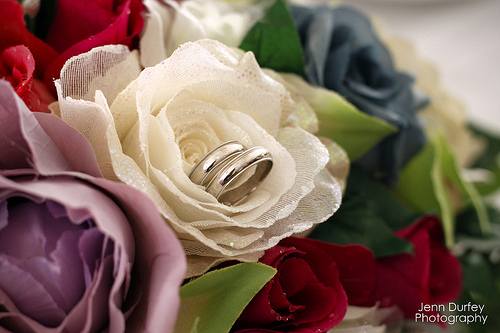

In [15]:
roses=list(data_dir.glob('rose/*'))
PIL.Image.open(str(roses[0]))

In [16]:
batch_size=32
img_height=180
img_weidth=180


In [17]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    seed=123,
    subset='training',
    image_size=(img_height,img_weidth),
    batch_size=batch_size

)

Found 2746 files belonging to 5 classes.
Using 2197 files for training.


In [18]:
val_ds=tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    seed=123,
    subset='validation',
    image_size=(img_height,img_weidth),
    batch_size=batch_size

)

Found 2746 files belonging to 5 classes.
Using 549 files for validation.


In [19]:
normalize_layer=tf.keras.layers.Rescaling(1./255)

In [20]:
normalize_ds=train_ds.map(lambda x,y:(normalize_layer(x),y))
image_batch,labels_batch=next(iter(normalize_ds))
first_image=image_batch[0]

In [21]:
autotune=tf.data.AUTOTUNE
train_ds=train_ds.cache().prefetch(buffer_size=autotune)
val_ds=val_ds.cache().prefetch(buffer_size=autotune)

In [22]:
from typing import Sequence
num_class=5
model=tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(num_class)
])


In [23]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [25]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

Epoch 1/3
69/69 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.3798 - loss: 1.4382 - val_accuracy: 0.4954 - val_loss: 1.2153
Epoch 2/3
69/69 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.5781 - loss: 1.0396 - val_accuracy: 0.5446 - val_loss: 1.1373
Epoch 3/3
69/69 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.6593 - loss: 0.8761 - val_accuracy: 0.6066 - val_loss: 1.1128


In [26]:
list_ds=tf.data.Dataset.list_files(str(data_dir/'*/*'),shuffle=False)
list_ds=list_ds.shuffle(image_count,reshuffle_each_iteration=False)

In [27]:
for f in list_ds.take(5):
  print(f.numpy())

b'/root/.cache/kagglehub/datasets/imsparsh/flowers-dataset/versions/2/train/dandelion/13967344688_aa629dcdee_n.jpg'
b'/root/.cache/kagglehub/datasets/imsparsh/flowers-dataset/versions/2/train/tulip/8614237582_74417799f4_m.jpg'
b'/root/.cache/kagglehub/datasets/imsparsh/flowers-dataset/versions/2/train/tulip/8838914676_8ef4db7f50_n.jpg'
b'/root/.cache/kagglehub/datasets/imsparsh/flowers-dataset/versions/2/train/dandelion/4645161319_c308fc31ef_n.jpg'
b'/root/.cache/kagglehub/datasets/imsparsh/flowers-dataset/versions/2/train/tulip/14866400927_3a59899df3_m.jpg'


In [28]:
val_size=int(image_count*0.2)
train_ds=list_ds.skip(val_size)
val_ds=list_ds.take(val_size)
#اسکیپ یعنی به غیر از اون 20 درصد هر چی بود رو بردارد یعنی 80 درصد رو بردار